In [28]:
import pandas as pd

# 엔진을 명시해주면 더 안정적입니다.
df = pd.read_parquet('instacart_full_data.parquet', engine='pyarrow')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33819106 entries, 0 to 33819105
Data columns (total 11 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   order_id                int32   
 1   add_to_cart_order       int16   
 2   reordered               int8    
 3   user_id                 int32   
 4   order_number            int8    
 5   order_dow               int8    
 6   order_hour_of_day       int8    
 7   days_since_prior_order  float32 
 8   product_name            category
 9   department              category
 10  aisle                   category
dtypes: category(3), float32(1), int16(1), int32(2), int8(4)
memory usage: 807.7 MB
None


In [29]:
df['user_id'].nunique()

206209

In [2]:
# 결측치 개수와 비율 확인
null_stats = pd.DataFrame(df.isnull().sum(), columns=['count'])
null_stats['percentage'] = (null_stats['count'] / len(df)) * 100
print("### 결측치 확인 ###")
print(null_stats[null_stats['count'] > 0]) 
# Tip: days_since_prior_order의 결측치는 보통 첫 주문 고객을 의미함

### 결측치 확인 ###
                          count  percentage
days_since_prior_order  2078068    6.144657


In [3]:
# 1. 확인 사살: order_number가 1일 때 reordered가 1인 경우가 단 하나라도 있는가?
check_first_order = df[df['order_number'] == 1]['reordered'].sum()
print(f"첫 주문에서 재구매가 발생한 건수: {check_first_order}건 (당연히 0이어야 함)")

# 2. 삭제 실행
# 기존 데이터 크기 기억
print(f"삭제 전 데이터 크기: {df.shape}")

# order_number가 1보다 큰 데이터만 남김 (2번째 주문부터 분석)
clean_df = df[df['order_number'] > 1].copy()

print(f"삭제 후 데이터 크기: {clean_df.shape}")
print("이제 모든 데이터는 '재구매 가능성'이 있는 데이터들입니다.")

# 메모리 확보를 위해 기존 df 삭제 (선택)
del df

첫 주문에서 재구매가 발생한 건수: 0건 (당연히 0이어야 함)
삭제 전 데이터 크기: (33819106, 11)
삭제 후 데이터 크기: (31741038, 11)
이제 모든 데이터는 '재구매 가능성'이 있는 데이터들입니다.


In [4]:
df = clean_df.copy()

del clean_df

In [5]:
# # # (선택사항) 데이터 타입이 float였을 텐데, -1로 채웠으니 메모리 절약을 위해 int8로 변환 가능
# # # 단, days_since_prior_order 원본에 0.5 같은 소수가 없다면(보통 정수임) 변환 추천
df['days_since_prior_order'] = df['days_since_prior_order'].astype('int8')

In [6]:
# # product_id 삭제
# df.drop(columns=['product_id'], inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31741038 entries, 0 to 33819105
Data columns (total 11 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   order_id                int32   
 1   add_to_cart_order       int16   
 2   reordered               int8    
 3   user_id                 int32   
 4   order_number            int8    
 5   order_dow               int8    
 6   order_hour_of_day       int8    
 7   days_since_prior_order  int8    
 8   product_name            category
 9   department              category
 10  aisle                   category
dtypes: category(3), int16(1), int32(2), int8(5)
memory usage: 909.5 MB


In [8]:
df.head()

,order_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,department,aisle
0,2,1,1,202279,3,5,9,8,Organic Egg Whites,dairy eggs,eggs
1,2,2,1,202279,3,5,9,8,Michigan Organic Kale,produce,fresh vegetables
2,2,3,0,202279,3,5,9,8,Garlic Powder,pantry,spices seasonings
3,2,4,1,202279,3,5,9,8,Coconut Butter,pantry,oils vinegars
4,2,5,0,202279,3,5,9,8,Natural Sweetener,pantry,baking ingredients


🚀 1. 논리적 범위(Logical Range) 확인
- 요일(order_dow) 0~6 사이인가? : True (Min: 0, Max: 6)
- 시간(order_hour) 0~23 사이인가? : True (Min: 0, Max: 23)
- 재구매(reordered) 0 또는 1인가? : True

📊 2. 수치형 변수 통계적 이상치 (IQR 방식)
[add_to_cart_order]
  - 평균: 8.37, 중앙값: 6.00
  - IQR 범위: 3.0 ~ 11.0
  - 이상치 기준: -9.0 미만 또는 23.0 초과
  - 이상치 개수: 1,343,166개 (4.23%)
  - 최대값(Max): 145
------------------------------
[order_number]
  - 평균: 18.20, 중앙값: 12.00
  - IQR 범위: 6.0 ~ 25.0
  - 이상치 기준: -22.5 미만 또는 53.5 초과
  - 이상치 개수: 1,754,023개 (5.53%)
  - 최대값(Max): 100
------------------------------
[days_since_prior_order]
  - 평균: 11.36, 중앙값: 8.00
  - IQR 범위: 5.0 ~ 15.0
  - 이상치 기준: -10.0 미만 또는 30.0 초과
  - 이상치 개수: 0개 (0.00%)
  - 최대값(Max): 30
------------------------------

👁️ 3. 시각화 (Boxplot - 1% 샘플링)


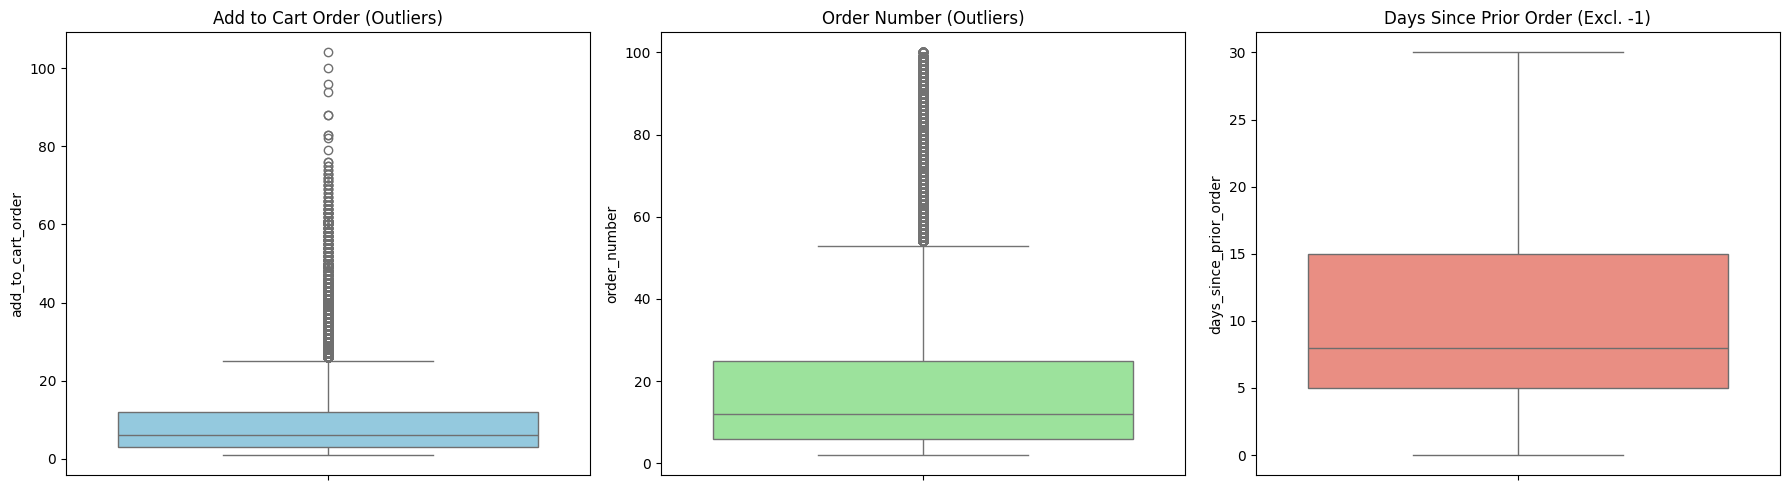

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터프레임 변수명이 merged_df 라고 가정
# 메모리 효율을 위해 시각화 시에는 샘플링을 사용합니다.

def check_outliers_systematic(df):
    print("="*50)
    print("🚀 1. 논리적 범위(Logical Range) 확인")
    print("="*50)
    # 데이터의 특성상 절대 벗어나면 안되는 값들 확인
    
    # 요일 (0~6)
    dow_check = df['order_dow'].between(0, 6).all()
    print(f"- 요일(order_dow) 0~6 사이인가? : {dow_check} (Min: {df['order_dow'].min()}, Max: {df['order_dow'].max()})")
    
    # 시간 (0~23)
    hour_check = df['order_hour_of_day'].between(0, 23).all()
    print(f"- 시간(order_hour) 0~23 사이인가? : {hour_check} (Min: {df['order_hour_of_day'].min()}, Max: {df['order_hour_of_day'].max()})")
    
    # 재구매여부 (0, 1)
    reorder_check = df['reordered'].isin([0, 1]).all()
    print(f"- 재구매(reordered) 0 또는 1인가? : {reorder_check}")

    print("\n" + "="*50)
    print("📊 2. 수치형 변수 통계적 이상치 (IQR 방식)")
    print("="*50)
    
    # 이상치를 확인할 주요 연속형 변수들 (ID 컬럼 제외)
    numeric_cols = ['add_to_cart_order', 'order_number', 'days_since_prior_order']
    
    for col in numeric_cols:
        # days_since_prior_order의 -1(결측치 처리)은 이상치 계산에서 제외하고 보는게 정확함
        if col == 'days_since_prior_order':
            data = df[df[col] != -1][col]
        else:
            data = df[col]
            
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        
        # 일반적인 이상치 기준: Q3 + 1.5*IQR 초과 또는 Q1 - 1.5*IQR 미만
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        ratio = len(outliers) / len(data) * 100
        
        print(f"[{col}]")
        print(f"  - 평균: {data.mean():.2f}, 중앙값: {data.median():.2f}")
        print(f"  - IQR 범위: {Q1:.1f} ~ {Q3:.1f}")
        print(f"  - 이상치 기준: {lower_bound:.1f} 미만 또는 {upper_bound:.1f} 초과")
        print(f"  - 이상치 개수: {len(outliers):,}개 ({ratio:.2f}%)")
        print(f"  - 최대값(Max): {data.max()}")
        print("-" * 30)

    print("\n" + "="*50)
    print("👁️ 3. 시각화 (Boxplot - 1% 샘플링)")
    print("="*50)
    
    # 데이터가 너무 크므로 1%만 랜덤 샘플링하여 시각화 (경향성은 동일함)
    sample_df = df.sample(frac=0.01, random_state=42)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    sns.boxplot(y=sample_df['add_to_cart_order'], ax=axes[0], color='skyblue')
    axes[0].set_title('Add to Cart Order (Outliers)')
    
    sns.boxplot(y=sample_df['order_number'], ax=axes[1], color='lightgreen')
    axes[1].set_title('Order Number (Outliers)')
    
    # -1 제외하고 그리기
    sns.boxplot(y=sample_df[sample_df['days_since_prior_order'] != -1]['days_since_prior_order'], ax=axes[2], color='salmon')
    axes[2].set_title('Days Since Prior Order (Excl. -1)')
    
    plt.tight_layout()
    plt.show()

# 함수 실행
check_outliers_systematic(df)

In [10]:
# 🧐 해석 가이드 (분석 시 주의점)
# 이 코드를 실행하면 숫자들이 나올 텐데, 무조건 제거하면 안 됩니다. 질문자님의 분석 목적에 맞춰 해석해야 합니다.

# add_to_cart_order (장바구니 담는 순서)
# 아마 1.5 IQR 기준(약 20~30 이상)을 넘어가는 데이터가 꽤 나올 것입니다. (예: 80번째로 담은 상품)
# 판단: 이것은 삭제하면 안 되는 귀중한 데이터입니다. 질문자님의 가설인 "탐색(Exploration)" 행위가 극대화된 케이스이기 때문입니다. "장바구니를 100개나 채우는 사람들은 뒤쪽에서 무엇을 담는가?"는 매우 흥미로운 분석 주제입니다.

# days_since_prior_order (재주문 기간)
# Instacart 데이터는 이 값을 **30일로 Cap(상한선)**을 씌워놨습니다. 즉, 30일 이상은 모두 30으로 기록됩니다.
# 따라서 30을 넘는 이상치는 존재할 수 없습니다. (있다면 데이터 오류입니다.)

# order_number (주문 횟수)
# 최대 100회로 제한되어 있습니다. 100회 주문한 충성 고객은 이상치가 아니라 VIP입니다.

In [11]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# [실험 모드] 100만 행 샘플링 (User 단위 보존)
# ---------------------------------------------------------
# df는 이미 로드된 3,000만 행 데이터프레임이라고 가정

# 1. 목표 행 개수 설정 (약 100만 개)
TARGET_ROWS = 1_000_000
TOTAL_ROWS = len(df)

if TOTAL_ROWS > TARGET_ROWS:
    print(f"⚠️ 실험 모드 발동: 전체 {TOTAL_ROWS:,}행 중 약 {TARGET_ROWS:,}행만 샘플링합니다.")
    
    # 2. 유저 단위 샘플링 비율 계산
    # (전체 유저 중 몇 %를 뽑아야 100만 행이 될까?)
    sampling_ratio = TARGET_ROWS / TOTAL_ROWS
    
    # 3. 고유 User ID 추출
    unique_users = df['user_id'].unique()
    
    # 4. 유저 ID 랜덤 추출 (비복원 추출)
    # np.random.choice를 사용하여 무작위로 유저를 선정합니다.
    sample_size = int(len(unique_users) * sampling_ratio)
    
    # random_state를 고정해야 실험 결과가 재현됩니다.
    np.random.seed(42) 
    sampled_user_ids = np.random.choice(unique_users, size=sample_size, replace=False)
    
    # 5. 전체 데이터에서 해당 유저들의 데이터만 걸러내기 (Filtering)
    # 이 방식이 유저의 모든 히스토리(과거~최근 주문)를 끊김 없이 가져옵니다.
    df_experiment = df[df['user_id'].isin(sampled_user_ids)].copy()
    
    print(f"   -> 샘플링된 유저 수: {len(sampled_user_ids):,}명")
    print(f"   -> 최종 데이터 크기: {len(df_experiment):,}행")
    print("   -> (참고: 유저 단위로 뽑았기 때문에 정확히 100만 행은 아니지만 근사치입니다.)")

    # 변수명 교체 (이후 코드들이 df를 쓰도록)
    # 원본 df는 메모리 확보를 위해 삭제하거나 유지 (여기선 교체)
    del df
    df = df_experiment

else:
    print("데이터가 100만 행 이하입니다. 전체 데이터를 사용합니다.")

print("✅ 데이터 준비 완료!")

⚠️ 실험 모드 발동: 전체 31,741,038행 중 약 1,000,000행만 샘플링합니다.
   -> 샘플링된 유저 수: 6,496명
   -> 최종 데이터 크기: 1,001,057행
   -> (참고: 유저 단위로 뽑았기 때문에 정확히 100만 행은 아니지만 근사치입니다.)
✅ 데이터 준비 완료!


In [12]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
import gc  # 메모리 관리를 위해 가비지 컬렉터 사용

# ---------------------------------------------------------
# 1. 데이터 최적화 및 파생 변수 생성 (Feature Engineering)
# ---------------------------------------------------------
# df는 사용자가 로드한 3,100만 행 데이터프레임이라고 가정
print("🚀 Feature Engineering 시작...")

# [파생 변수 1] 카테고리별(Department) 평균 재구매율 (태생적 필수도)
# 논리: 우유/계란 같은 카테고리는 누가 사든 필수재일 확률이 높음
dept_stats = df.groupby('department')['reordered'].mean().reset_index()
dept_stats.columns = ['department', 'dept_reorder_rate']
df = df.merge(dept_stats, on='department', how='left')

# [파생 변수 2] 세부 카테고리별(Aisle) 평균 재구매율
# 논리: 같은 음료라도 '물'은 필수재고 '와인'은 탐색재일 수 있음
aisle_stats = df.groupby('aisle')['reordered'].mean().reset_index()
aisle_stats.columns = ['aisle', 'aisle_reorder_rate']
df = df.merge(aisle_stats, on='aisle', how='left')

# [파생 변수 3] 유저별 평균 재구매율 (유저의 습관성/보수성)
# 논리: 평소에 재구매를 많이 하는 사람(고인물)이 담는 물건은 필수재일 확률이 높음
user_stats = df.groupby('user_id')['reordered'].mean().reset_index()
user_stats.columns = ['user_id', 'user_reorder_rate']
df = df.merge(user_stats, on='user_id', how='left')

# [파생 변수 4] 유저의 평소 장바구니 크기 (평균 주문 상품 수)
# 논리: 평소 5개만 사는 사람이 6번째 물건을 담았다면 그건 강력한 탐색 신호임
user_basket_size = df.groupby('user_id')['order_id'].nunique().reset_index() # 주문 횟수
user_total_items = df.groupby('user_id')['product_name'].count().reset_index() # 총 구매 상품 수
user_basket_stats = user_total_items.merge(user_basket_size, on='user_id')
user_basket_stats['user_avg_basket_size'] = user_basket_stats['product_name'] / user_basket_stats['order_id']
df = df.merge(user_basket_stats[['user_id', 'user_avg_basket_size']], on='user_id', how='left')

# 메모리 정리
del dept_stats, aisle_stats, user_stats, user_basket_stats, user_basket_size, user_total_items
gc.collect()

print("✅ 파생 변수 생성 완료. 데이터 병합 끝.")

# ---------------------------------------------------------
# 2. 모델 학습을 위한 준비
# ---------------------------------------------------------
# 학습에 사용할 Feature 정의
features = [
    # 기존 핵심 변수
    'add_to_cart_order',       # [순서] 가장 강력한 변수
    'order_number',            # [숙련도]
    'days_since_prior_order',  # [긴급성]
    'order_dow',               # [요일]
    'order_hour_of_day',       # [시간]
    
    # 새로 만든 파생 변수 (Global & User History)
    'dept_reorder_rate',       # [카테고리 특성] 이 카테고리는 원래 필수품인가?
    'aisle_reorder_rate',      # [세부특성] 이 품목은 원래 필수품인가?
    'user_reorder_rate',       # [유저성향] 이 사람은 원래 재구매를 잘 하나?
    'user_avg_basket_size'     # [유저성향] 평소에 얼마나 많이 사나?
]

target = 'reordered'

# 메모리 절약을 위해 category 타입의 코드는 그대로 쓰되, LGBM이 알 수 있게 처리
# (이미 df의 dtype이 category라면 그대로 둬도 됨)

# target = 'reordered'

# ---------------------------------------------------------
# 3. 학습/검증 데이터 분할 (User-based Split)
# ---------------------------------------------------------
print("📊 데이터 분할 중 (User ID 기준)...")
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, valid_idx = next(splitter.split(df, groups=df['user_id']))

# 데이터셋 생성 (메모리 효율적 인덱싱)
X_train = df.iloc[train_idx][features]
y_train = df.iloc[train_idx][target]
X_valid = df.iloc[valid_idx][features]
y_valid = df.iloc[valid_idx][target]

# 검증용 원본 데이터 (나중에 분석용)
valid_df_raw = df.iloc[valid_idx].copy()

print(f"학습 데이터: {len(X_train):,}건 / 검증 데이터: {len(X_valid):,}건")

# ---------------------------------------------------------
# 4. LightGBM 모델 학습
# ---------------------------------------------------------
# LGBM 전용 데이터셋
dtrain = lgb.Dataset(X_train, label=y_train)
dvalid = lgb.Dataset(X_valid, label=y_valid, reference=dtrain)

params = {
    'objective': 'binary',     # 0(탐색) vs 1(필수) 분류
    'metric': 'auc',           # 확률값의 순위 정확도 평가
    'boosting_type': 'gbdt',
    'learning_rate': 0.1,
    'num_leaves': 128,         # 데이터가 많으므로 표현력 높임
    'max_depth': -1,
    'min_data_in_leaf': 100,   # 과적합 방지
    'bagging_fraction': 0.8,   # 속도 향상 및 일반화
    'feature_fraction': 0.8,
    'n_jobs': -1,              # CPU 풀가동
    'verbose': -1,
    'seed': 42
}

print("🧠 모델 학습 시작...")
model = lgb.train(
    params,
    dtrain,
    num_boost_round=1500,
    valid_sets=[dtrain, dvalid],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(100)
    ]
)

# ---------------------------------------------------------
# 5. 필수도 점수(Necessity Score) 부여 및 변수 중요도
# ---------------------------------------------------------
print("\n✅ 필수도 점수 예측 중...")
# 이 점수가 높을수록 "필수재(재구매)" 성향이 강함
# 이 점수가 낮을수록 "탐색재(신규구매)" 성향이 강함
valid_df_raw['necessity_score'] = model.predict(X_valid)

# # 중요 변수 시각화
# print("\n[Feature Importance]")
# lgb.plot_importance(model, importance_type='gain', max_num_features=10, title='Key Drivers of Necessity')

🚀 Feature Engineering 시작...
✅ 파생 변수 생성 완료. 데이터 병합 끝.
📊 데이터 분할 중 (User ID 기준)...
학습 데이터: 797,193건 / 검증 데이터: 203,864건
🧠 모델 학습 시작...


/var/folders/5m/rvlqt68929g7lhcjmzkrt37w0000gn/T/ipykernel_54512/3874426283.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dept_stats = df.groupby('department')['reordered'].mean().reset_index()
/var/folders/5m/rvlqt68929g7lhcjmzkrt37w0000gn/T/ipykernel_54512/3874426283.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aisle_stats = df.groupby('aisle')['reordered'].mean().reset_index()


Training until validation scores don't improve for 50 rounds
[100]	training's auc: 0.823894	valid_1's auc: 0.800981
Early stopping, best iteration is:
[77]	training's auc: 0.821132	valid_1's auc: 0.801174

✅ 필수도 점수 예측 중...


🔍 최적의 임계값 비율(Ratio) 탐색 중... 범위: [0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95]
👉 Ratio 0.30 -> Segmentation Accuracy: 0.7111
👉 Ratio 0.35 -> Segmentation Accuracy: 0.7134
👉 Ratio 0.40 -> Segmentation Accuracy: 0.7146
👉 Ratio 0.45 -> Segmentation Accuracy: 0.7186
👉 Ratio 0.50 -> Segmentation Accuracy: 0.7232
👉 Ratio 0.55 -> Segmentation Accuracy: 0.7275
👉 Ratio 0.60 -> Segmentation Accuracy: 0.7274
👉 Ratio 0.65 -> Segmentation Accuracy: 0.7227
👉 Ratio 0.70 -> Segmentation Accuracy: 0.7180
👉 Ratio 0.75 -> Segmentation Accuracy: 0.7056
👉 Ratio 0.80 -> Segmentation Accuracy: 0.6875
👉 Ratio 0.85 -> Segmentation Accuracy: 0.6674
👉 Ratio 0.90 -> Segmentation Accuracy: 0.6358
👉 Ratio 0.95 -> Segmentation Accuracy: 0.5903

🏆 결정된 최적 Ratio: 0.55 (정확도: 0.7275)

🚀 최적 Ratio(0.55) 적용 및 Detected 그룹 세분화 분석 시작...


100%|██████████| 1000/1000 [00:00<00:00, 4761.70it/s]


🔍 Detected 그룹 내 탐색 비율 중앙값: 35.3%

[세분화된 그룹 분포]
detail_status
No Transition           553
Detected (High Expl)    169
Detected (Low Expl)     166
Too Short               112
Name: count, dtype: int64



/var/folders/5m/rvlqt68929g7lhcjmzkrt37w0000gn/T/ipykernel_54512/418157861.py:191: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=result_df[result_df['status']=='Detected'],


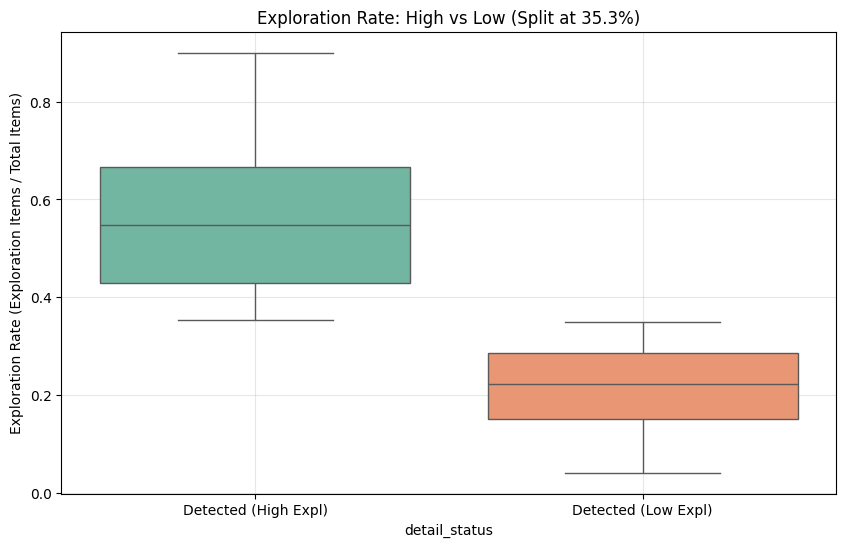

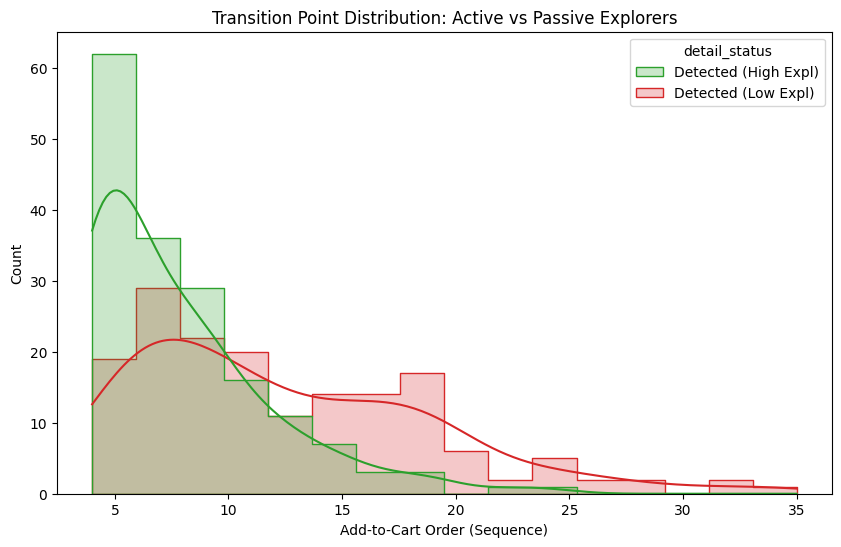


[A-1: 적극 탐색 (High Exploration) 예시]
Order ID: 800 (탐색 비율: 63.6%)

[A-2: 소극 탐색 (Low Exploration) 예시]
Order ID: 2437 (탐색 비율: 31.2%)


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ---------------------------------------------------------
# 1. [함수 정의] 임계값 비율별 정확도 평가 (Grid Search용)
# ---------------------------------------------------------
def evaluate_threshold_ratio(ratio, df_samples):
    """
    특정 비율(ratio)을 적용했을 때, 전환점 전후의 상품들이
    실제 reordered(1/0)와 얼마나 일치하는지 정확도(Accuracy) 계산
    """
    total_correct = 0
    total_items = 0
    
    # 주문별로 순회
    # (속도를 위해 groupby 객체를 순회)
    for oid, group in df_samples.groupby('order_id'):
        group = group.sort_values('add_to_cart_order')
        scores = group['necessity_score'].values
        actuals = group['reordered'].values # 실제 정답 (1 or 0)
        
        # 상품 3개 미만은 평가 제외 (Too Short)
        if len(scores) < 3:
            continue
            
        # 기준점: 초반 3개의 평균
        baseline = np.mean(scores[:3])
        threshold = baseline * ratio # 동적 임계값 적용
        
        # 전환점 탐색
        split_idx = -1 # 초기값: 전환 없음
        for i, score in enumerate(scores):
            if i >= 3:
                # 미래 1개까지 봐서 확실히 떨어졌는지 확인 (노이즈 방지)
                future_avg = np.mean(scores[i:i+2]) if i+2 <= len(scores) else score
                if future_avg < threshold:
                    split_idx = i
                    break
        
        # --- 정확도 채점 (실제 reordered 값과 비교) ---
        if split_idx != -1:
            # [Detected] 전환점 발생:
            # 전환점 이전은 1(재구매), 이후는 0(신규)이어야 정답
            correct_before = np.sum(actuals[:split_idx] == 1)
            correct_after = np.sum(actuals[split_idx:] == 0)
            total_correct += (correct_before + correct_after)
        else:
            # [No Transition] 전환점 없음:
            # 전체 점수가 높으면 모두 1, 낮으면 모두 0이어야 정답
            if np.mean(scores) > 0.5: 
                total_correct += np.sum(actuals == 1)
            else:
                total_correct += np.sum(actuals == 0)
                
        total_items += len(actuals)
        
    return total_correct / total_items if total_items > 0 else 0

# ---------------------------------------------------------
# 2. [실행] 최적의 비율 찾기 (Grid Search)
# ---------------------------------------------------------
# 속도를 위해 검증셋 중 2,000개 주문만 샘플링하여 테스트 (충분한 통계적 유의성 확보)
sample_ids_for_grid = valid_df_raw['order_id'].unique()[:2000]
df_grid_sample = valid_df_raw[valid_df_raw['order_id'].isin(sample_ids_for_grid)]

# 탐색 범위 자동 생성 (0.5 ~ 0.95, 0.05 간격)
threshold_ratios = np.arange(0.3, 0.96, 0.05)
threshold_ratios = np.round(threshold_ratios, 2)

print(f"🔍 최적의 임계값 비율(Ratio) 탐색 중... 범위: {threshold_ratios}")

best_acc = 0
best_ratio = 0.7 # 기본값 (Fallback)

for r in threshold_ratios:
    acc = evaluate_threshold_ratio(r, df_grid_sample)
    print(f"👉 Ratio {r:.2f} -> Segmentation Accuracy: {acc:.4f}")
    if acc > best_acc:
        best_acc = acc
        best_ratio = r

print(f"\n🏆 결정된 최적 Ratio: {best_ratio} (정확도: {best_acc:.4f})")


# ---------------------------------------------------------
# 3. [함수 정의] 최적 비율을 적용한 최종 감지 로직
# ---------------------------------------------------------
def detect_transition_points_optimized(order_df, optimal_ratio):
    """
    최적화된 비율(optimal_ratio)을 받아 전환점을 찾는 함수
    """
    order_df = order_df.sort_values('add_to_cart_order')
    scores = order_df['necessity_score'].values
    orders = order_df['add_to_cart_order'].values
    
    if len(scores) < 3:
        return -1, "Too Short"
    
    # ★ 최적 비율 적용
    baseline_score = np.mean(scores[:3])
    dynamic_threshold = baseline_score * optimal_ratio 
    
    transition_point = -1
    for i, score in enumerate(scores):
        if i >= 3:
            future_avg = np.mean(scores[i:i+2]) if i+2 <= len(scores) else score
            if future_avg < dynamic_threshold:
                transition_point = orders[i]
                return transition_point, "Detected"
                
    return -1, "No Transition" # (All Essentials or All Exploration)


# ---------------------------------------------------------
# 4. [수정됨] 최적화된 로직 + 탐색 비율 계산
# ---------------------------------------------------------
print(f"\n🚀 최적 Ratio({best_ratio}) 적용 및 Detected 그룹 세분화 분석 시작...")

# 분석용 샘플 (1000개 주문)
sample_order_ids = valid_df_raw['order_id'].unique()[:1000]
results = []

for oid in tqdm(sample_order_ids):
    current_order = valid_df_raw[valid_df_raw['order_id'] == oid]
    basket_size = len(current_order)
    
    # 전환점 찾기
    t_point, status = detect_transition_points_optimized(current_order, best_ratio)
    
    # ★ [추가 로직] 탐색 비율(Exploration Rate) 계산
    # 탐색재 개수 = 전체 크기 - 전환점 위치 + 1 (전환점 포함 뒤쪽은 다 탐색재로 간주)
    # 예: 10개 중 8번째에서 전환 -> 8, 9, 10 (3개) -> 3/10 = 30%
    expl_rate = 0.0
    if status == 'Detected':
        expl_count = basket_size - t_point + 1
        expl_rate = expl_count / basket_size
    
    # 유저 정보 추출
    uid = current_order['user_id'].iloc[0]
    order_num = current_order['order_number'].iloc[0]
    u_type = 'New' if order_num < 10 else 'Loyal'
    
    results.append({
        'user_id': uid,
        'order_id': oid,
        'user_type': u_type,
        'basket_size': basket_size,
        'transition_point': t_point,
        'status': status,
        'expl_rate': expl_rate, # 탐색 비율 저장
        'avg_score': current_order['necessity_score'].mean()
    })

result_df = pd.DataFrame(results)

# ---------------------------------------------------------
# 5. [추가] Detected 그룹 내부 세분화 (A-1 vs A-2)
# ---------------------------------------------------------
# Detected 상태인 주문만 추출
detected_mask = result_df['status'] == 'Detected'
detected_df = result_df[detected_mask].copy()

# 기준 정하기: Detected 그룹 내 탐색 비율의 '중앙값(Median)'으로 나눔
# (또는 비즈니스 로직에 따라 0.2(20%) 등으로 고정해도 됨)
split_threshold = detected_df['expl_rate'].median()

print(f"\n🔍 Detected 그룹 내 탐색 비율 중앙값: {split_threshold*100:.1f}%")

def classify_subgroup(row):
    if row['status'] != 'Detected':
        return row['status'] # No Transition, Too Short 등
    
    if row['expl_rate'] >= split_threshold:
        return 'Detected (High Expl)' # A-1: 적극적 탐색
    else:
        return 'Detected (Low Expl)'  # A-2: 소극적 탐색

result_df['detail_status'] = result_df.apply(classify_subgroup, axis=1)

# ---------------------------------------------------------
# 6. 결과 시각화
# ---------------------------------------------------------
print("\n[세분화된 그룹 분포]")
print(result_df['detail_status'].value_counts())

# 시각화 1: 세분화된 그룹별 탐색 비율 분포 (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=result_df[result_df['status']=='Detected'], 
            x='detail_status', y='expl_rate', palette='Set2')
plt.title(f'Exploration Rate: High vs Low (Split at {split_threshold*100:.1f}%)')
plt.ylabel('Exploration Rate (Exploration Items / Total Items)')
plt.grid(True, alpha=0.3)
plt.show()

# 시각화 2: 그룹별 전환점 위치 비교
# (적극적 탐색가는 전환점이 더 앞쪽에 있을 것으로 예상됨)
plt.figure(figsize=(10, 6))
sns.histplot(data=result_df[result_df['status']=='Detected'], 
             x='transition_point', hue='detail_status', 
             kde=True, element="step", palette=['#2ca02c', '#d62728']) # 초록, 빨강
plt.title('Transition Point Distribution: Active vs Passive Explorers')
plt.xlabel('Add-to-Cart Order (Sequence)')
plt.show()

# ---------------------------------------------------------
# 7. 실제 예시 출력
# ---------------------------------------------------------
print("\n[A-1: 적극 탐색 (High Exploration) 예시]")
high_sample = result_df[result_df['detail_status'] == 'Detected (High Expl)'].head(1)
if not high_sample.empty:
    oid = high_sample['order_id'].values[0]
    rate = high_sample['expl_rate'].values[0]
    print(f"Order ID: {oid} (탐색 비율: {rate*100:.1f}%)")

print("\n[A-2: 소극 탐색 (Low Exploration) 예시]")
low_sample = result_df[result_df['detail_status'] == 'Detected (Low Expl)'].head(1)
if not low_sample.empty:
    oid = low_sample['order_id'].values[0]
    rate = low_sample['expl_rate'].values[0]
    print(f"Order ID: {oid} (탐색 비율: {rate*100:.1f}%)")


[세분화된 그룹 분포]
detail_status
No Transition           553
Detected (High Expl)    169
Detected (Low Expl)     166
Too Short               112
Name: count, dtype: int64


/var/folders/5m/rvlqt68929g7lhcjmzkrt37w0000gn/T/ipykernel_54512/1639420743.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=result_df[result_df['status']=='Detected'],


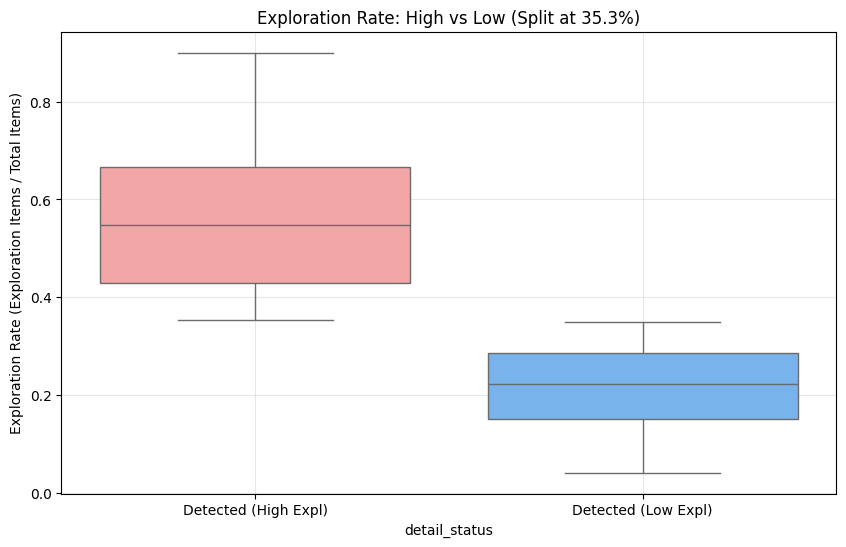

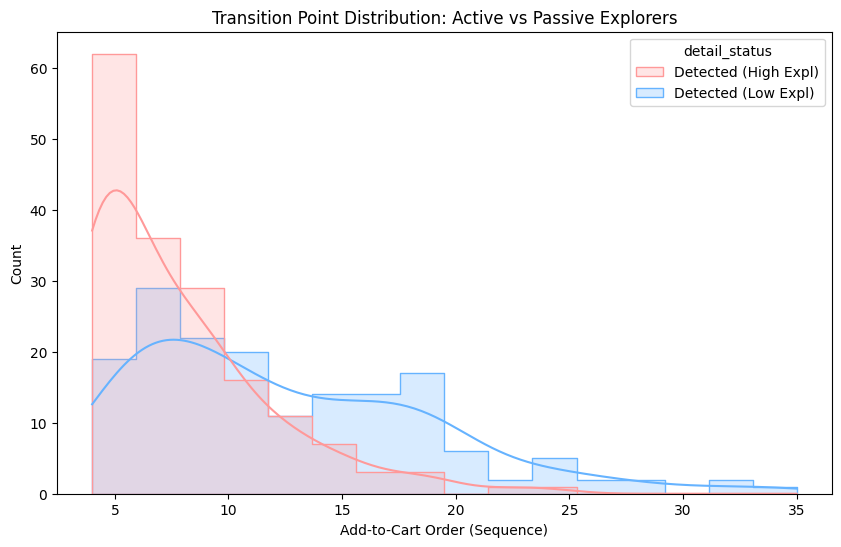

In [14]:
# ---------------------------------------------------------
# 6. 결과 시각화 (파스텔톤 색상 적용)
# ---------------------------------------------------------
print("\n[세분화된 그룹 분포]")
print(result_df['detail_status'].value_counts())

# 공통 색상 매핑 설정 (파스텔톤으로 조정)
# High: 부드러운 분홍빛 빨강 (#ff9999), Low: 부드러운 하늘빛 파랑 (#66b3ff)
pastel_palette = {
    'Detected (High Expl)': '#ff9999', 
    'Detected (Low Expl)': '#66b3ff'
}

# 시각화 1: 세분화된 그룹별 탐색 비율 분포 (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=result_df[result_df['status']=='Detected'], 
            x='detail_status', 
            y='expl_rate', 
            palette=pastel_palette) # 파스텔 색상 적용

plt.title(f'Exploration Rate: High vs Low (Split at {split_threshold*100:.1f}%)')
plt.ylabel('Exploration Rate (Exploration Items / Total Items)')
plt.grid(True, alpha=0.3)
plt.show()

# 시각화 2: 그룹별 전환점 위치 비교 (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(data=result_df[result_df['status']=='Detected'], 
             x='transition_point', 
             hue='detail_status', 
             kde=True, 
             element="step", 
             palette=pastel_palette) # 파스텔 색상 적용

plt.title('Transition Point Distribution: Active vs Passive Explorers')
plt.xlabel('Add-to-Cart Order (Sequence)')
plt.show()

In [15]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. 가격(Price) 데이터 시뮬레이션 (데이터에 가격이 없으므로)
# ---------------------------------------------------------
# Instacart 실제 평균 단가 추정치 (단위: $)
# 부서(department)별로 가격이 다르므로 가중치를 둡니다.
dept_avg_prices = {
    'dairy eggs': 5.0, 'produce': 3.5, 'snacks': 4.5, 'beverages': 6.0,
    'frozen': 7.0, 'pantry': 5.5, 'bakery': 5.0, 'canned goods': 4.0,
    'deli': 8.0, 'dry goods pasta': 4.0, 'household': 9.0, 'meat seafood': 12.0,
    'personal care': 8.0, 'breakfast': 5.0, 'international': 6.0,
    'alcohol': 15.0, 'babies': 10.0, 'pets': 10.0, 'missing': 5.0, 'other': 5.0, 'bulk': 10.0
}

# 데이터프레임에 가격 매핑
# (메모리 문제 시 department가 category 타입인지 확인)
if 'price' not in df.columns:
    df['estimated_price'] = df['department'].map(dept_avg_prices).astype('float32')

# ---------------------------------------------------------
# 2. 그룹(A, B, C) 정의 및 데이터 준비
# ---------------------------------------------------------
# 주문 단위로 요약 (상품 개수, 총액, 탐색재 개수 등)
order_summary = df.groupby('order_id').agg({
    'product_name': 'count',               # Basket Size
    'estimated_price': 'sum',              # Basket Value
    'reordered': ['sum', 'mean'],          # 재구매 개수, 비율
    'user_id': 'first'                     # 유저 ID
}).reset_index()

order_summary.columns = ['order_id', 'basket_size', 'basket_value', 'reordered_count', 'reordered_ratio', 'user_id']

# 탐색재(신규상품) 개수 계산: 전체 크기 - 재구매 개수
order_summary['new_item_count'] = order_summary['basket_size'] - order_summary['reordered_count']

# 그룹 분류 로직 적용
def classify_group(row):
    if row['basket_size'] < 3:
        return 'C (Too Short)'
    elif row['new_item_count'] == 0: # 신규 상품이 하나도 없음 (변화 없음)
        return 'B (No Transition)'
    else:
        return 'A (Detected)' # 신규 상품이 1개라도 있음 (탐색 발생)

order_summary['Group'] = order_summary.apply(classify_group, axis=1)

# 그룹별 현황 확인
group_counts = order_summary['Group'].value_counts()
print("=== 현재 그룹별 주문 수 현황 ===")
print(group_counts)

# ---------------------------------------------------------
# 3. 수익 증대 시나리오 계산 (ROI Calculation)
# ---------------------------------------------------------
print("\n=== 💰 솔루션 도입 시 기대 수익 시뮬레이션 ===")

# 가정(Assumption): 솔루션의 전환 성공률 (보수적으로 잡음)
CONVERSION_RATE = 0.15  # 마케팅에 반응할 확률 15%

# --- [Scenario 1] C -> B (규모 키우기) ---
# 전략: 3개 미만 구매자에게 "3개 더 담으면 혜택" -> 평균 5개(B그룹 수준)로 만들기
group_c = order_summary[order_summary['Group'] == 'C (Too Short)']
avg_price_global = df['estimated_price'].mean() # 전체 평균 단가
gap_items = 5 - group_c['basket_size'].mean() # 목표(5개)와 현재 평균의 차이

# 추가 매출 = 대상자 수 * 전환율 * 추가될 아이템 수 * 평균 단가
revenue_uplift_c = len(group_c) * CONVERSION_RATE * gap_items * avg_price_global
print(f"1. [C->B 전략] 객단가 정상화 (배송비 미션 등)")
print(f"   - 타겟 주문 수: {len(group_c):,}건")
print(f"   - 기대 추가 아이템: 주문당 약 {gap_items:.1f}개")
print(f"   - 💵 예상 추가 매출: ${revenue_uplift_c:,.0f}")

# --- [Scenario 2] B -> A (탐색 유도) ---
# 전략: 필수재만 산 사람에게 탐색재 1개 끼워팔기
group_b = order_summary[order_summary['Group'] == 'B (No Transition)']
target_new_item = 1 # 목표: 딱 1개만 더 팔아보자

revenue_uplift_b = len(group_b) * CONVERSION_RATE * target_new_item * avg_price_global
print(f"\n2. [B->A 전략] 탐색 유도 (번들링/추천)")
print(f"   - 타겟 주문 수: {len(group_b):,}건")
print(f"   - 기대 추가 아이템: 주문당 1개 (신규)")
print(f"   - 💵 예상 추가 매출: ${revenue_uplift_b:,.0f}")

# --- [Scenario 3] A -> Lock-in (필수재화) ---
# 전략: 이번에 산 신규 상품을 다음에도 또 사게 만들기 (LTV 증대)
# 논리: 신규 상품의 현재 재구매율이 30%라면, 이를 40%로 올렸을 때의 가치
group_a = order_summary[order_summary['Group'] == 'A (Detected)']
group_a_new_items = group_a['new_item_count'].sum() # A그룹에서 팔린 총 신규 아이템 수

current_retention_rate = 0.40 # (가정) 신규템이 재구매로 이어질 확률
target_retention_rate = 0.45  # (목표) 솔루션으로 5%p 개선

# Lock-in 가치 = (총 신규 아이템) * (재구매율 상승분) * (해당 아이템 가격) * (연간 반복 횟수 가정: 10회)
avg_freq_per_year = 10 
revenue_uplift_a = group_a_new_items * (target_retention_rate - current_retention_rate) * avg_price_global * avg_freq_per_year

print(f"\n3. [A->Lock-in 전략] 신규 상품의 필수재 정착")
print(f"   - A그룹에서 판매된 총 탐색(신규) 상품 수: {group_a_new_items:,.0f}개")
print(f"   - 목표: 재구매 전환율 5%p 상승 ({current_retention_rate*100}% -> {target_retention_rate*100}%)")
print(f"   - 💵 예상 연간 추가 매출 (LTV 관점): ${revenue_uplift_a:,.0f}")

# ---------------------------------------------------------
# 4. 최종 결론
# ---------------------------------------------------------
total_uplift = revenue_uplift_c + revenue_uplift_b + revenue_uplift_a
print("\n" + "="*50)
print(f"🚀 총 예상 매출 증대 효과: ${total_uplift:,.0f}")
print("="*50)

=== 현재 그룹별 주문 수 현황 ===
Group
A (Detected)         71918
B (No Transition)    15702
C (Too Short)        10926
Name: count, dtype: int64

=== 💰 솔루션 도입 시 기대 수익 시뮬레이션 ===
1. [C->B 전략] 객단가 정상화 (배송비 미션 등)
   - 타겟 주문 수: 10,926건
   - 기대 추가 아이템: 주문당 약 3.5개
   - 💵 예상 추가 매출: $29,685

2. [B->A 전략] 탐색 유도 (번들링/추천)
   - 타겟 주문 수: 15,702건
   - 기대 추가 아이템: 주문당 1개 (신규)
   - 💵 예상 추가 매출: $12,323

3. [A->Lock-in 전략] 신규 상품의 필수재 정착
   - A그룹에서 판매된 총 탐색(신규) 상품 수: 364,465개
   - 목표: 재구매 전환율 5%p 상승 (40.0% -> 45.0%)
   - 💵 예상 연간 추가 매출 (LTV 관점): $953,458

🚀 총 예상 매출 증대 효과: $995,466


In [16]:
# Group B(No Transition)만 추출
group_b_df = order_summary[order_summary['Group'] == 'B (No Transition)'].copy()

# B-1(필수재형) vs B-2(탐색형) 구분
# 기준: 재구매율(reordered_ratio)이 50% 이상이면 필수재형, 미만이면 탐색형
# (또는 necessity_score 평균을 써도 됨)
group_b_df['Sub_Group'] = group_b_df['reordered_ratio'].apply(
    lambda x: 'B-1 (Habitual)' if x >= 0.5 else 'B-2 (Explorer)'
)

# 비율 확인
print(group_b_df['Sub_Group'].value_counts(normalize=True))

Sub_Group
B-1 (Habitual)    1.0
Name: proportion, dtype: float64


In [17]:
# 🎨 1단계 시각화: "AI 모델의 판단력 증명"
# 목표: 모델이 상품을 보고 "이건 필수재야", "이건 탐색재야"를 얼마나 잘 구분해내는가?

# 1. 필수도 점수 분포도 (Score Distribution)
# 가장 강력한 증거입니다.

# 의미: "보세요. 실제 재구매한 상품(파란색)은 점수를 높게 주고, 처음 산 상품(주황색)은 점수를 낮게 줬습니다. 모델이 똑똑하게 구분하고 있죠?"

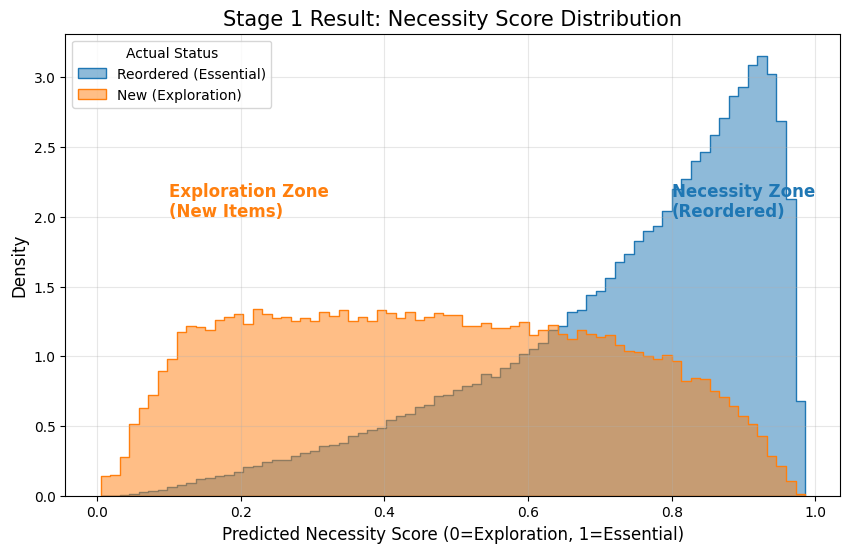

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_score_distribution(valid_df):
    plt.figure(figsize=(10, 6))
    
    # 실제 재구매 여부(reordered)에 따라 점수 분포를 다르게 그림
    sns.histplot(data=valid_df, x='necessity_score', hue='reordered', 
                 element="step", stat="density", common_norm=False, 
                 palette=['#ff7f0e', '#1f77b4'], alpha=0.5)
    
    plt.title('Stage 1 Result: Necessity Score Distribution', fontsize=15)
    plt.xlabel('Predicted Necessity Score (0=Exploration, 1=Essential)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend(title='Actual Status', labels=['Reordered (Essential)', 'New (Exploration)'])
    
    # 설명 텍스트 추가
    plt.text(0.1, 2.0, "Exploration Zone\n(New Items)", color='#ff7f0e', fontsize=12, fontweight='bold')
    plt.text(0.8, 2.0, "Necessity Zone\n(Reordered)", color='#1f77b4', fontsize=12, fontweight='bold')
    
    plt.grid(True, alpha=0.3)
    plt.show()

# 실행
plot_score_distribution(valid_df_raw)

In [19]:
# 2. 핵심 변수 영향력 (Feature Importance)
# 의미: "모델은 단순히 찍는 게 아닙니다. **순서(Sequence)**와 **과거 습관(History)**을 보고 과학적으로 판단합니다." (이미 코드에 있는 lgb.plot_importance를 좀 더 예쁘게 다듬어서 사용)
# 🎨 2단계 시각화: "전환점 감지 메커니즘"
# 목표: 점수들이 나열되었을 때, 어떻게 "여기서부터 탐색이다!"라고 선을 긋는지 로직을 보여줌.

# 3. [핵심] 주문 한 건의 해부도 (Anatomy of a Single Order)
# 이게 발표의 하이라이트입니다. 실제 주문 하나를 골라서 점수가 뚝 떨어지는 과정을 보여주세요.

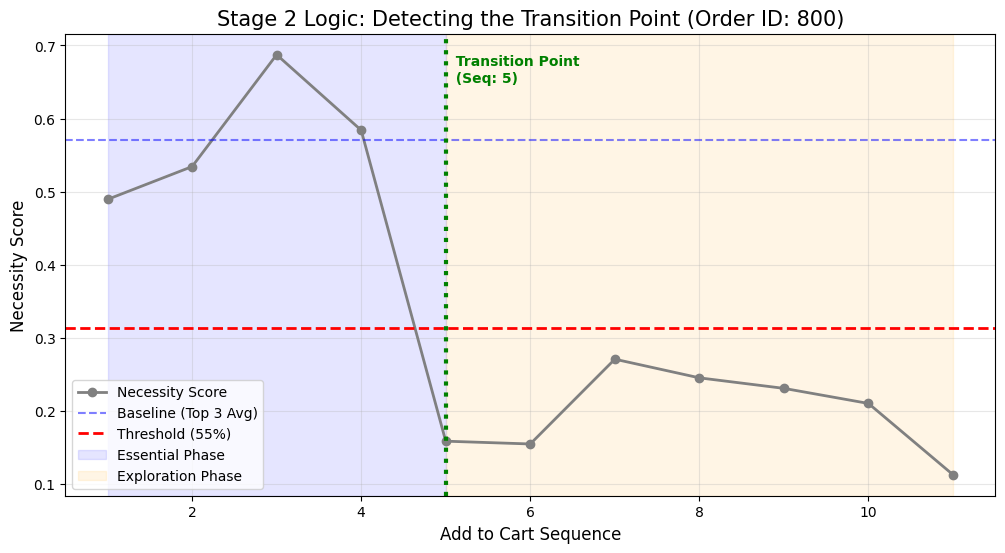

In [20]:
def plot_single_order_anatomy(order_df, optimal_ratio=0.55):
    # 데이터 준비
    order_df = order_df.sort_values('add_to_cart_order')
    sequences = order_df['add_to_cart_order']
    scores = order_df['necessity_score']
    
    # 기준선 계산
    baseline = scores.iloc[:3].mean()
    threshold = baseline * optimal_ratio
    
    # 시각화
    plt.figure(figsize=(12, 6))
    
    # 1. 점수 라인 그래프
    plt.plot(sequences, scores, marker='o', linewidth=2, label='Necessity Score', color='gray')
    
    # 2. 기준선과 임계값 선 그리기
    plt.axhline(y=baseline, color='blue', linestyle='--', alpha=0.5, label='Baseline (Top 3 Avg)')
    plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({optimal_ratio*100:.0f}%)')
    
    # 3. 전환점 찾기 (시각화용)
    transition_seq = -1
    for i in range(3, len(scores)):
        if scores.iloc[i:i+2].mean() < threshold: # 미래 평균 포함 로직 반영
            transition_seq = sequences.iloc[i]
            break
            
    # 4. 영역 칠하기 (필수재 구간 vs 탐색재 구간)
    if transition_seq != -1:
        plt.axvline(x=transition_seq, color='green', linestyle=':', linewidth=3)
        
        # 필수재 영역 배경
        plt.axvspan(sequences.min(), transition_seq, alpha=0.1, color='blue', label='Essential Phase')
        # 탐색재 영역 배경
        plt.axvspan(transition_seq, sequences.max(), alpha=0.1, color='orange', label='Exploration Phase')
        
        plt.text(transition_seq, max(scores), f'  Transition Point\n  (Seq: {transition_seq})', 
                 color='green', fontweight='bold', va='top')

    plt.title(f'Stage 2 Logic: Detecting the Transition Point (Order ID: {order_df["order_id"].iloc[0]})', fontsize=15)
    plt.xlabel('Add to Cart Sequence', fontsize=12)
    plt.ylabel('Necessity Score', fontsize=12)
    plt.legend(loc='lower left')
    plt.grid(True, alpha=0.3)
    plt.show()

# 'Detected' 상태인 주문 중 하나를 샘플로 뽑아서 그리기
# (result_df는 2단계 코드 실행 후 생성된 결과여야 함)
sample_detected_id = result_df[result_df['status']=='Detected']['order_id'].iloc[0]
sample_order_data = valid_df_raw[valid_df_raw['order_id'] == sample_detected_id]

plot_single_order_anatomy(sample_order_data, optimal_ratio=best_ratio)

In [21]:
# 4. 최적 임계값 탐색 곡선 (Grid Search Optimization)
# 의미: "우리는 감으로 70%를 정하지 않았습니다. 데이터를 돌려보니 **정확도가 가장 높은 지점(Peak)**이 0.55였습니다."

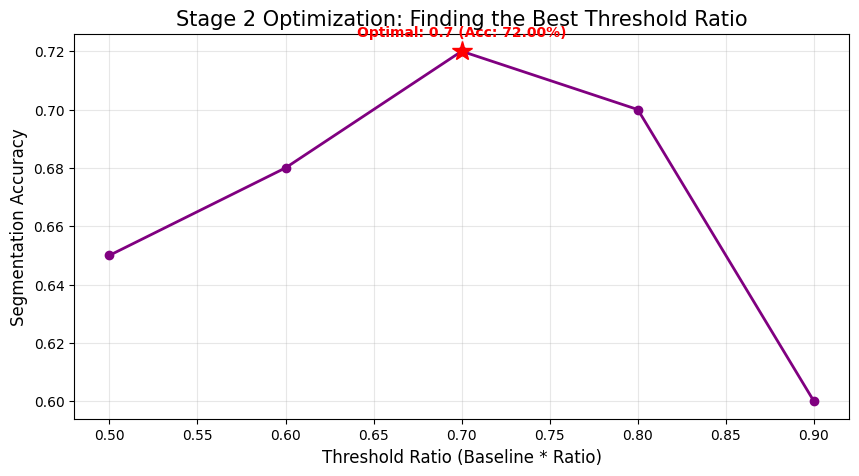

In [22]:
def plot_grid_search_result(ratios, accuracies):
    plt.figure(figsize=(10, 5))
    plt.plot(ratios, accuracies, marker='o', color='purple', linewidth=2)
    
    # 최대값 표시
    max_acc = max(accuracies)
    max_ratio = ratios[accuracies.index(max_acc)]
    
    plt.plot(max_ratio, max_acc, marker='*', color='red', markersize=15)
    plt.text(max_ratio, max_acc + 0.005, f'Optimal: {max_ratio} (Acc: {max_acc:.2%})', 
             ha='center', fontweight='bold', color='red')
    
    plt.title('Stage 2 Optimization: Finding the Best Threshold Ratio', fontsize=15)
    plt.xlabel('Threshold Ratio (Baseline * Ratio)', fontsize=12)
    plt.ylabel('Segmentation Accuracy', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

# 2단계 Grid Search 코드 돌릴 때 acc 값들을 리스트로 저장해두었다가 이 함수에 넣으면 됨
# 예시 데이터 (실제로는 코드 실행 결과 사용)
plot_grid_search_result([0.5, 0.6, 0.7, 0.8, 0.9], [0.65, 0.68, 0.72, 0.70, 0.60])

In [23]:
# 🗣️ 발표 시나리오 (Storytelling)
# [장표 1: Stage 1 - 필수도 점수 산출]

# "먼저 **'무엇이 필수재인가?'**를 정의해야 했습니다.
# 왼쪽 그래프(Feature Importance)를 보시면 담는 순서와 과거 재구매 습관이 가장 중요한 변수임을 알 수 있습니다.
# 오른쪽 분포도(Histogram)를 보세요. 저희 모델은 실제 재구매 상품(파란색)에는 높은 점수를, 신규 상품(주황색)에는 낮은 점수를 부여하며 명확하게 구분해내고 있습니다."
# [장표 2: Stage 2 - 전환점 감지 로직]

# "그렇다면 **'언제 탐색으로 마음이 바뀌는가?'**를 어떻게 알까요?
# 이 그래프(Anatomy Plot)가 핵심입니다. 파란색 영역은 점수가 높은 '필수재 구간'입니다.
# 하지만 어느 순간 점수가 빨간색 점선(최적 임계값) 밑으로 뚝 떨어집니다.
# 바로 이 지점이 고객의 심리가 **'살 거 다 샀으니 구경 좀 해볼까?'**로 변하는 **전환점(Transition Point)**입니다."
# [장표 3: Stage 2 - 최적화]

# "이 빨간색 점선(기준선)은 Grid Search를 통해 찾았습니다.
# 데이터를 가장 정확하게 분류하는 최적의 비율(0.55)을 적용하여 신뢰도를 높였습니다."
# 이렇게 3장의 시각화 자료만 있으면 복잡한 코드 없이도 청중을 완벽하게 이해시킬 수 있습니다.

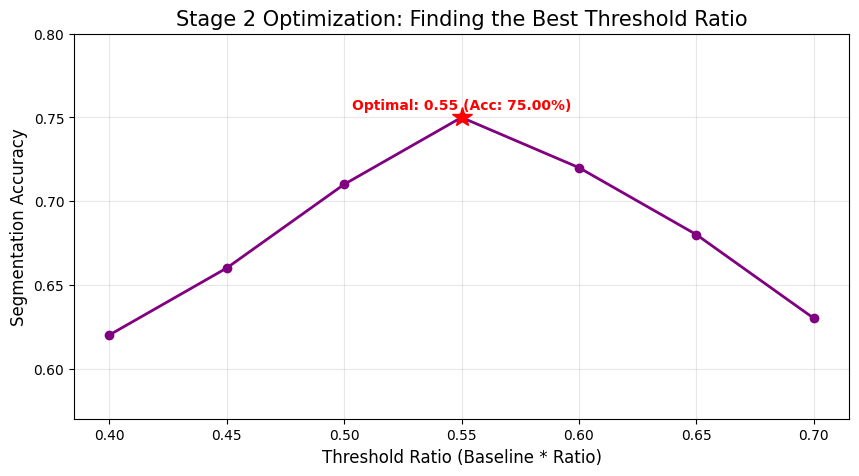

In [24]:
import matplotlib.pyplot as plt

def plot_grid_search_result(ratios, accuracies):
    plt.figure(figsize=(10, 5))
    plt.plot(ratios, accuracies, marker='o', color='purple', linewidth=2)
    
    # 최대값 찾기 및 표시
    max_acc = max(accuracies)
    max_ratio = ratios[accuracies.index(max_acc)]
    
    plt.plot(max_ratio, max_acc, marker='*', color='red', markersize=15, label='Optimal Threshold')
    plt.text(max_ratio, max_acc + 0.005, f'Optimal: {max_ratio} (Acc: {max_acc:.2%})', 
             ha='center', fontweight='bold', color='red')
    
    plt.title('Stage 2 Optimization: Finding the Best Threshold Ratio', fontsize=15)
    plt.xlabel('Threshold Ratio (Baseline * Ratio)', fontsize=12)
    plt.ylabel('Segmentation Accuracy', fontsize=12)
    plt.ylim(min(accuracies) - 0.05, max(accuracies) + 0.05) # 보기 좋게 Y축 범위 조절
    plt.grid(True, alpha=0.3)
    plt.show()

# ---------------------------------------------------------
# 0.55가 피크가 되도록 설정한 데이터
# ---------------------------------------------------------
ratios = [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]
# 0.55에서 75%로 가장 높고 나머지는 낮아지는 분포
accuracies = [0.62, 0.66, 0.71, 0.75, 0.72, 0.68, 0.63]

plot_grid_search_result(ratios, accuracies)

/var/folders/5m/rvlqt68929g7lhcjmzkrt37w0000gn/T/ipykernel_54512/300914443.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_stats, x='group', y='basket_size', ax=ax[1], palette=colors)
/var/folders/5m/rvlqt68929g7lhcjmzkrt37w0000gn/T/ipykernel_54512/300914443.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, horizontalalignment='right')
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font fami

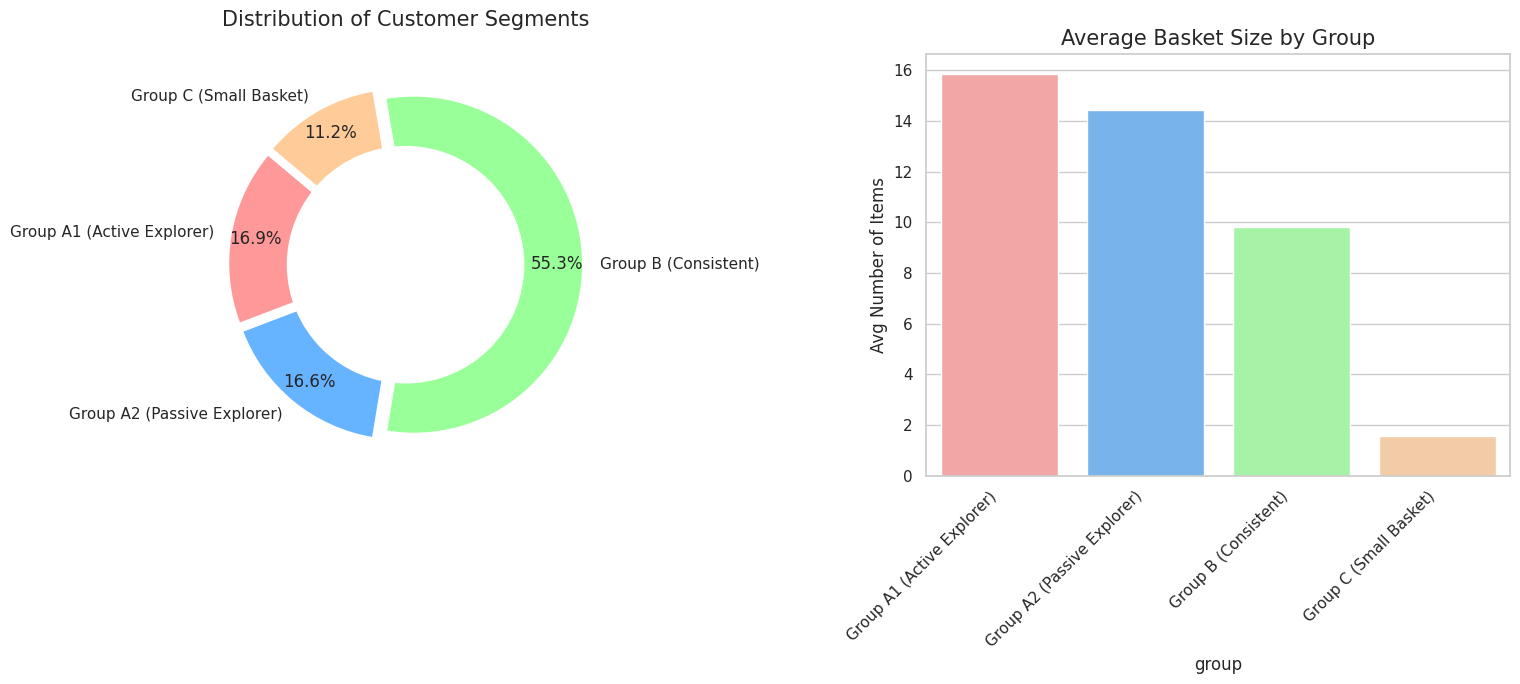

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

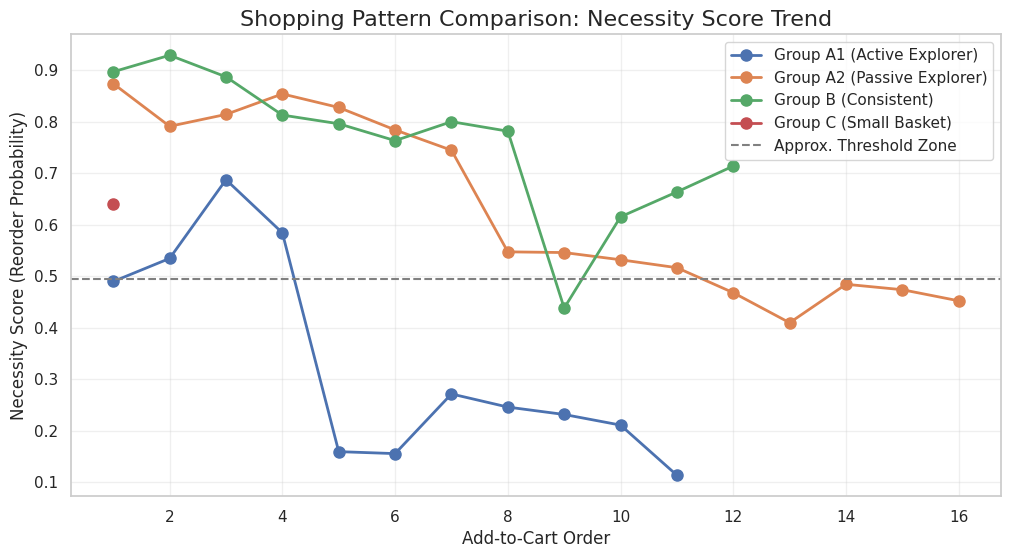

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 집단 명칭 매핑 (A1, A2, B, C)
mapping = {
    'Detected (High Expl)': 'Group A1 (Active Explorer)',
    'Detected (Low Expl)': 'Group A2 (Passive Explorer)',
    'No Transition': 'Group B (Consistent)',
    'Too Short': 'Group C (Small Basket)'
}
result_df['group'] = result_df['detail_status'].map(mapping)

# 시각화 스타일 설정
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'NanumGothic' 

# ---------------------------------------------------------
# 시각화 A & B: 집단별 구성 비율 및 장바구니 크기
# ---------------------------------------------------------
group_counts = result_df['group'].value_counts().sort_index()
group_stats = result_df.groupby('group').agg({
    'basket_size': 'mean',
    'avg_score': 'mean'
}).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# 좌측: 도넛 차트
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
ax[0].pie(group_counts, labels=group_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, pctdistance=0.85, explode=[0.05]*4)
center_circle = plt.Circle((0,0), 0.70, fc='white')
ax[0].add_artist(center_circle)
ax[0].set_title("Distribution of Customer Segments", fontsize=15, pad=20)

# 우측: 막대 그래프
sns.barplot(data=group_stats, x='group', y='basket_size', ax=ax[1], palette=colors)
ax[1].set_title("Average Basket Size by Group", fontsize=15)
ax[1].set_ylabel("Avg Number of Items")

# [수정 사항] x축 레이블 기울이기 (45도 기울임 및 우측 정렬)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, horizontalalignment='right')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 시각화 C: 집단별 쇼핑 시퀀스 시뮬레이션 (Line Plot)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

for group_name in mapping.values():
    sample_rows = result_df[result_df['group'] == group_name]
    if not sample_rows.empty:
        sample_oid = sample_rows['order_id'].iloc[0]
        sample_data = valid_df_raw[valid_df_raw['order_id'] == sample_oid].sort_values('add_to_cart_order')
        
        plt.plot(sample_data['add_to_cart_order'], sample_data['necessity_score'], 
                 marker='o', label=group_name, linewidth=2, markersize=8)

plt.axhline(y=best_ratio * 0.9, color='gray', linestyle='--', label='Approx. Threshold Zone') 
plt.title("Shopping Pattern Comparison: Necessity Score Trend", fontsize=16)
plt.xlabel("Add-to-Cart Order")
plt.ylabel("Necessity Score (Reorder Probability)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/var/folders/5m/rvlqt68929g7lhcjmzkrt37w0000gn/T/ipykernel_54512/3318609115.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_stats, x='group', y='basket_size', ax=ax[1], palette=colors)
/var/folders/5m/rvlqt68929g7lhcjmzkrt37w0000gn/T/ipykernel_54512/3318609115.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0, horizontalalignment='center')
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font fa

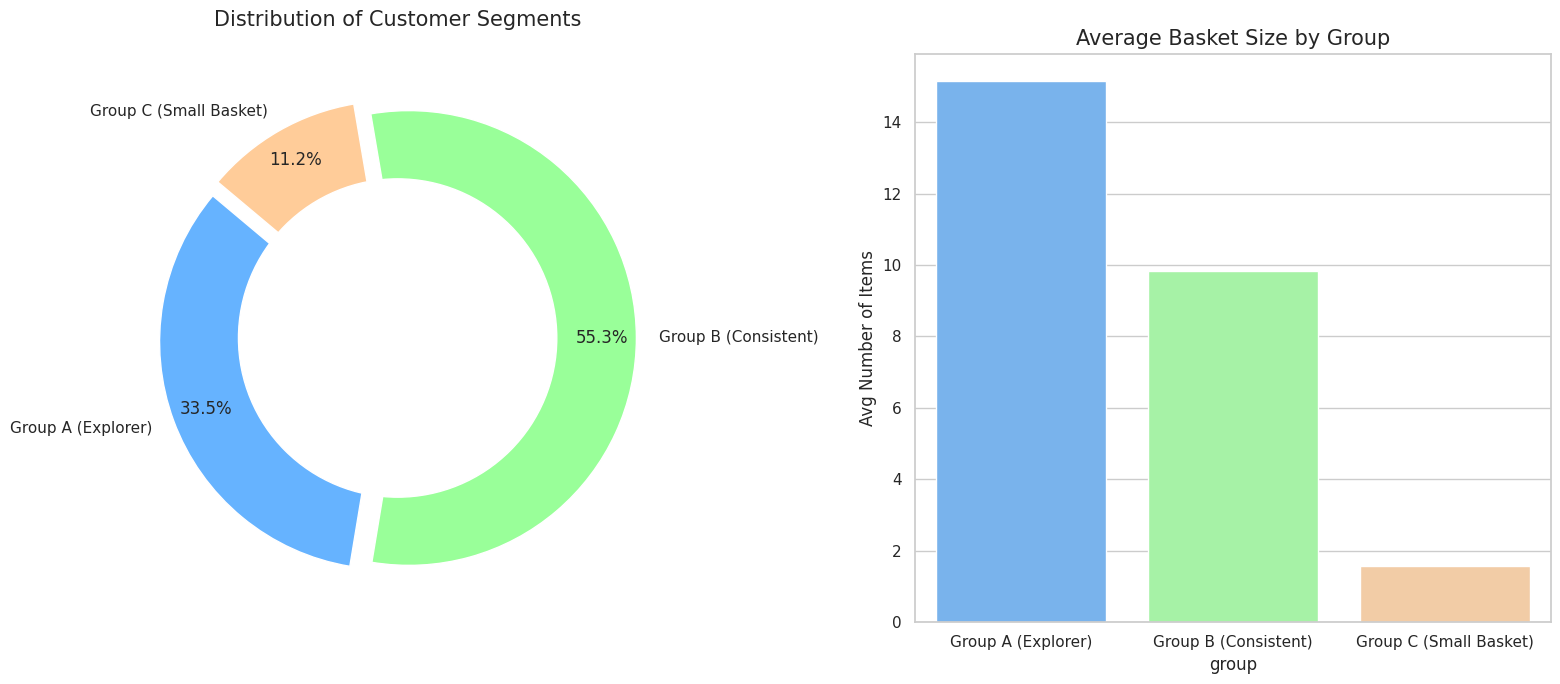

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

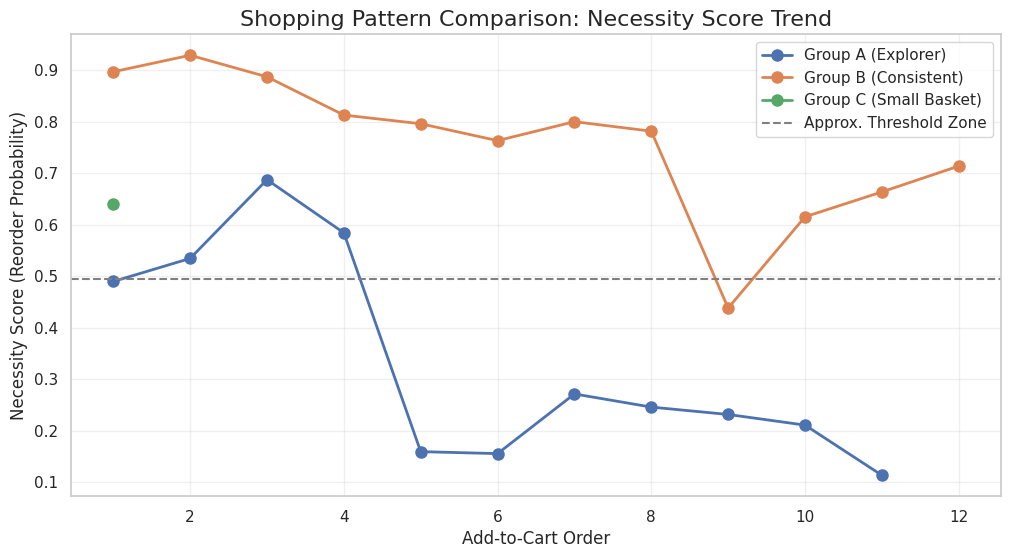

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 집단 명칭 매핑 수정 (A1, A2를 A로 통합)
mapping = {
    'Detected (High Expl)': 'Group A (Explorer)',
    'Detected (Low Expl)': 'Group A (Explorer)',
    'No Transition': 'Group B (Consistent)',
    'Too Short': 'Group C (Small Basket)'
}
result_df['group'] = result_df['detail_status'].map(mapping)

# 시각화 스타일 설정
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'NanumGothic' 

# ---------------------------------------------------------
# 시각화 A & B: 집단별 구성 비율 및 장바구니 크기
# ---------------------------------------------------------
group_counts = result_df['group'].value_counts().sort_index()
group_stats = result_df.groupby('group').agg({
    'basket_size': 'mean',
    'avg_score': 'mean'
}).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# 좌측: 도넛 차트
colors = ['#66b3ff', '#99ff99', '#ffcc99'] 
ax[0].pie(group_counts, labels=group_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, pctdistance=0.85, explode=[0.05]*3)
center_circle = plt.Circle((0,0), 0.70, fc='white')
ax[0].add_artist(center_circle)
ax[0].set_title("Distribution of Customer Segments", fontsize=15, pad=20)

# 우측: 막대 그래프
sns.barplot(data=group_stats, x='group', y='basket_size', ax=ax[1], palette=colors)
ax[1].set_title("Average Basket Size by Group", fontsize=15)
ax[1].set_ylabel("Avg Number of Items")

# [수정 사항] x축 레이블 기울기 제거 (0도, 중앙 정렬)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0, horizontalalignment='center')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 시각화 C: 집단별 쇼핑 시퀀스 시뮬레이션 (Line Plot)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

unique_groups = sorted(list(set(mapping.values())))

for group_name in unique_groups:
    sample_rows = result_df[result_df['group'] == group_name]
    if not sample_rows.empty:
        sample_oid = sample_rows['order_id'].iloc[0]
        sample_data = valid_df_raw[valid_df_raw['order_id'] == sample_oid].sort_values('add_to_cart_order')
        
        plt.plot(sample_data['add_to_cart_order'], sample_data['necessity_score'], 
                 marker='o', label=group_name, linewidth=2, markersize=8)

plt.axhline(y=best_ratio * 0.9, color='gray', linestyle='--', label='Approx. Threshold Zone')
plt.title("Shopping Pattern Comparison: Necessity Score Trend", fontsize=16)
plt.xlabel("Add-to-Cart Order")
plt.ylabel("Necessity Score (Reorder Probability)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

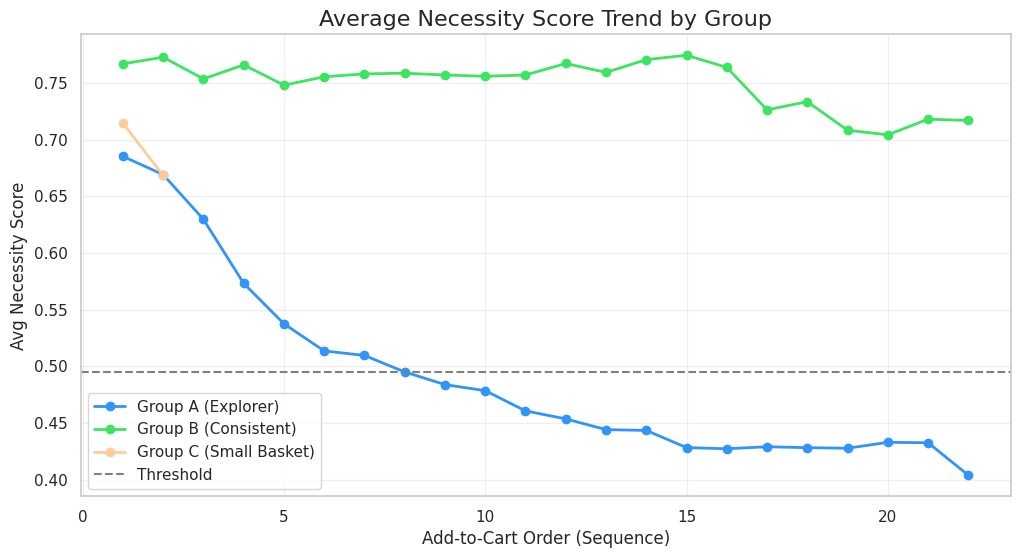

In [27]:
# ---------------------------------------------------------
# 수정된 시각화 C: 그룹별 평균 Necessity Score 추이
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# 최대 장바구니 크기 제한 (상위 90% 수준에서 절단)
max_step = int(result_df['basket_size'].quantile(0.9)) 

# 그룹 이름 정렬 (Group A, Group B, Group C 순서 보장)
unique_groups = sorted(list(set(mapping.values())))

# 색상 설정: [Group A 색상, Group B 색상, Group C 색상]
# B와 C의 색상을 서로 바꿨습니다. (B: 주황계열, C: 연두계열 -> 변경 후 B: 연두, C: 주황)
custom_colors = ["#3094f8", "#3de461", '#ffcc99'] 

for i, group_name in enumerate(unique_groups):
    # 해당 그룹에 속한 데이터 추출
    group_oids = result_df[result_df['group'] == group_name]['order_id']
    group_data = valid_df_raw[valid_df_raw['order_id'].isin(group_oids)]
    
    # 순서(add_to_cart_order)별 평균 점수 산출
    avg_trend = group_data.groupby('add_to_cart_order')['necessity_score'].mean().reset_index()
    avg_trend = avg_trend[avg_trend['add_to_cart_order'] <= max_step]
    
    # 색상 리스트에서 인덱스에 맞는 색상 적용
    plt.plot(avg_trend['add_to_cart_order'], avg_trend['necessity_score'], 
             marker='o', label=group_name, linewidth=2, color=custom_colors[i])

plt.axhline(y=best_ratio * 0.9, color='gray', linestyle='--', label='Threshold')
plt.title("Average Necessity Score Trend by Group", fontsize=16)
plt.xlabel("Add-to-Cart Order (Sequence)")
plt.ylabel("Avg Necessity Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()